# Olist Initial Purchase Logistic Regression

## Project Objective

This notebook develops a **Logistic Regression baseline model** to predict whether a customer will make a repeat purchase within 90 days of their initial purchase.

The model uses information available at the time of the customer's initial purchase. The goal is to evaluate whether initial-purchase customer and order characteristics contain enough information to meaningfully predict future purchasing behavior.

The modeling dataset was constructed in PostgreSQL and is loaded into Python for data preparation, modeling, and evaluation.

## Modeling Approach

This notebook will:

1. Load and inspect the initial-purchase modeling dataset.
2. Investigate missing values and define the final modeling population.
3. Define the target and model features.
4. Split the data chronologically into training and testing sets.
5. Preprocess numeric and categorical features.
6. Train a Logistic Regression baseline.
7. Evaluate the model using classification and ranking metrics.
8. Examine model coefficients and predicted probabilities.

In [1]:
# Import the libraries used throughout the notebook.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc
)

In [2]:
# Create a SQLAlchemy connection to the PostgreSQL Olist project database.

engine = create_engine(
    "postgresql+psycopg2://marcusromeo@localhost:5432/olist_project"
)

In [3]:
# Confirm that the PostgreSQL connection is working.

with engine.connect() as connection:
    print("PostgreSQL connection successful")

PostgreSQL connection successful


In [4]:
# Load the modeling dataset created in PostgreSQL.

df = pd.read_sql(
    "SELECT * FROM customer_initial_purchase_model",
    engine
)

In [5]:
# Inspect the first few rows to verify that the data loaded correctly.

df.head()

,customer_unique_id,repeat_purchase_90d,customer_state,first_order_date,first_order_amount,product_amount,freight_amount,products_ordered,unique_products_ordered,number_of_categories,number_of_sellers,payment_installments,freight_to_order_ratio
0,98af3235f3dc55bc74cb8932c64b3523,No,BA,2018-04-22 14:26:17,125.33,102.90,22.43,1.0,1.0,1.0,1.0,4.0,0.178968
1,494e875bef93610d10c951763389f74e,No,RJ,2017-05-15 12:55:13,77.75,60.08,17.67,1.0,1.0,1.0,1.0,5.0,0.227267
2,3a1aed3a4ca113b4909b06889ecba01b,No,SP,2018-05-14 15:36:23,104.76,89.98,14.78,2.0,1.0,1.0,1.0,1.0,0.141084
3,2ab7fad20e1c4c7747dfc91137b862cf,No,SP,2017-03-19 12:41:44,119.99,99.99,20.00,1.0,1.0,1.0,1.0,2.0,0.166681
4,f714fd5260fc9d9f1b9628afe96e488a,No,RS,2017-11-27 14:54:37,85.92,69.99,15.93,1.0,1.0,1.0,1.0,4.0,0.185405


In [6]:
# Inspect the structure, row count, data types, and non-null counts.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87008 entries, 0 to 87007
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customer_unique_id       87008 non-null  object        
 1   repeat_purchase_90d      87008 non-null  object        
 2   customer_state           87008 non-null  object        
 3   first_order_date         87008 non-null  datetime64[ns]
 4   first_order_amount       86351 non-null  float64       
 5   product_amount           86351 non-null  float64       
 6   freight_amount           86351 non-null  float64       
 7   products_ordered         86351 non-null  float64       
 8   unique_products_ordered  86351 non-null  float64       
 9   number_of_categories     86351 non-null  float64       
 10  number_of_sellers        86351 non-null  float64       
 11  payment_installments     87007 non-null  float64       
 12  freight_to_order_ratio   86351 n

## Missing-Value Investigation

The initial modeling dataset contains **87,008 customers and 13 columns**.

Missing values are concentrated in the initial-purchase variables. Because these variables represent information available at the time of the customer's initial purchase and are intended to be used as model features, customers with missing initial-purchase information are investigated before defining the final modeling population.

In [7]:
# Identify how many missing values are present in each column.

df.isna().sum()

customer_unique_id           0
repeat_purchase_90d          0
customer_state               0
first_order_date             0
first_order_amount         657
product_amount             657
freight_amount             657
products_ordered           657
unique_products_ordered    657
number_of_categories       657
number_of_sellers          657
payment_installments         1
freight_to_order_ratio     657
dtype: int64

In [8]:
# Create the modeling dataset by excluding customers missing
# the first-order amount, which represents missing initial-purchase information.

df_model = df.dropna(subset=["first_order_amount"])

In [9]:
# Confirm the size of the modeling population after removing customers
# missing initial-purchase information.

df_model.shape

(86351, 13)

In [10]:
# Verify that missing initial-purchase information has been removed.

df_model.isna().sum()

customer_unique_id         0
repeat_purchase_90d        0
customer_state             0
first_order_date           0
first_order_amount         0
product_amount             0
freight_amount             0
products_ordered           0
unique_products_ordered    0
number_of_categories       0
number_of_sellers          0
payment_installments       1
freight_to_order_ratio     0
dtype: int64

In [11]:
# Inspect the one remaining customer with missing payment-installment information.

df_model[df_model["payment_installments"].isna()]

,customer_unique_id,repeat_purchase_90d,customer_state,first_order_date,first_order_amount,product_amount,freight_amount,products_ordered,unique_products_ordered,number_of_categories,number_of_sellers,payment_installments,freight_to_order_ratio
64086,830d5b7aaa3b6f1e9ad63703bec97d23,No,SP,2016-09-15 12:16:38,143.46,134.97,8.49,3.0,1.0,1.0,1.0,NaN,0.05918


In [12]:
# Create the final modeling dataset by excluding the one remaining
# customer with missing payment-installment information.

df_final = df_model.dropna()

In [13]:
# Confirm the final modeling population size.

df_final.shape

(86350, 13)

In [14]:
# Verify that the final modeling dataset contains no missing values.

df_final.isna().sum()

customer_unique_id         0
repeat_purchase_90d        0
customer_state             0
first_order_date           0
first_order_amount         0
product_amount             0
freight_amount             0
products_ordered           0
unique_products_ordered    0
number_of_categories       0
number_of_sellers          0
payment_installments       0
freight_to_order_ratio     0
dtype: int64

## Final Modeling Population

Customers with missing initial-purchase information were excluded because these variables are intended to serve as model features. This removed **657 customers** from the initial population of **87,008**.

After this exclusion, **86,351 customers** remained. One additional customer was missing payment-installment information despite having complete information for the other modeling variables. Because this feature is also intended for modeling, that customer was excluded.

The final modeling dataset contains **86,350 customers with complete information across all 13 columns**.

## Feature and Target Preparation

The target variable is `repeat_purchase_90d`, indicating whether a customer made a repeat purchase within 90 days of their initial purchase.

The baseline model uses customer and initial-purchase characteristics that would have been available at the prediction point.

`customer_unique_id` is retained in the original dataset for customer identification but is excluded from the model features.

`first_order_date` is also excluded from the baseline model. It may be revisited later as a temporal feature.

The remaining variables are used as model features.

In [15]:
# Define the binary target variable:
# 0 = no repeat purchase within 90 days
# 1 = repeat purchase within 90 days

y = df_final["repeat_purchase_90d"].map({"No": 0, "Yes": 1})

# Define the model features available at the prediction point.
# Customer ID and first-order date are intentionally excluded.

X = df_final[
    [
        "customer_state",
        "first_order_amount",
        "products_ordered",
        "unique_products_ordered",
        "number_of_categories",
        "number_of_sellers",
        "payment_installments",
        "freight_to_order_ratio"
    ]
]

In [16]:
# Confirm the number of observations and model features.

X.shape, y.shape

((86350, 8), (86350,))

## Chronological Train-Test Split

Because the goal is to predict **future customer behavior**, the data is split chronologically rather than randomly.

Customers are divided into approximately **80% training data and 20% testing data** based on their initial purchase date. The training set contains customers with earlier initial purchases, while the testing set contains customers with later initial purchases.

This approach better reflects the real-world use case of using historical customer behavior to predict purchasing behavior among future customers.

In [17]:
# Sort initial purchase dates and use the 80th percentile observation
# as the chronological cutoff between training and testing periods.

cutoff_date = (
    df_final["first_order_date"]
    .sort_values()
    .iloc[int(len(df_final) * 0.80)]
)

cutoff_date

Timestamp('2018-04-24 14:16:45')

In [18]:
# Create the chronological training and testing populations.

train = df_final[df_final["first_order_date"] <= cutoff_date].copy()
test = df_final[df_final["first_order_date"] > cutoff_date].copy()

In [19]:
# Confirm the number of observations in each split.

train.shape, test.shape

((69081, 13), (17269, 13))

In [20]:
# Confirm that the split is approximately 80% training and 20% testing.

len(train) / len(df_final), len(test) / len(df_final)

(0.800011580775912, 0.19998841922408803)

In [21]:
# Define the training and testing features using the same feature set
# established above.

X_train = train[
    [
        "customer_state",
        "first_order_amount",
        "products_ordered",
        "unique_products_ordered",
        "number_of_categories",
        "number_of_sellers",
        "payment_installments",
        "freight_to_order_ratio"
    ]
]

y_train = train["repeat_purchase_90d"].map({"No": 0, "Yes": 1})

X_test = test[
    [
        "customer_state",
        "first_order_amount",
        "products_ordered",
        "unique_products_ordered",
        "number_of_categories",
        "number_of_sellers",
        "payment_installments",
        "freight_to_order_ratio"
    ]
]

y_test = test["repeat_purchase_90d"].map({"No": 0, "Yes": 1})

In [22]:
# Confirm the dimensions of the training and testing data.

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((69081, 8), (69081,), (17269, 8), (17269,))

In [23]:
# Check the target distribution in both sets.
# This is important because repeat purchases are relatively rare.

print("Training set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTesting set:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Training set:
repeat_purchase_90d
0    67622
1     1459
Name: count, dtype: int64
repeat_purchase_90d
0    0.97888
1    0.02112
Name: proportion, dtype: float64

Testing set:
repeat_purchase_90d
0    17043
1      226
Name: count, dtype: int64
repeat_purchase_90d
0    0.986913
1    0.013087
Name: proportion, dtype: float64


## Data Preprocessing

The numeric features are standardized so that they are on comparable scales.

The categorical `customer_state` feature is one-hot encoded into separate binary variables.

The preprocessing transformations are **fit using only the training data** and then applied to both the training and testing data. This prevents information from the testing period from influencing the preprocessing step.

In [24]:
# Identify the categorical and numeric features.

categorical_features = ["customer_state"]

numeric_features = [
    "first_order_amount",
    "products_ordered",
    "unique_products_ordered",
    "number_of_categories",
    "number_of_sellers",
    "payment_installments",
    "freight_to_order_ratio"
]

In [25]:
# Build the preprocessing transformer.
# Numeric features are standardized and customer_state is one-hot encoded.

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [26]:
# Fit the preprocessing steps using the training data only.

preprocessor.fit(X_train)

ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                 ['first_order_amount', 'products_ordered',
                                  'unique_products_ordered',
                                  'number_of_categories', 'number_of_sellers',
                                  'payment_installments',
                                  'freight_to_order_ratio']),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['customer_state'])])

In [27]:
# Transform both training and testing data using the fitted preprocessor.

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [28]:
# Confirm that both datasets contain the same number of processed features.

X_train_processed.shape, X_test_processed.shape

((69081, 34), (17269, 34))

In [29]:
# Inspect the names of the processed features created by the transformer.

preprocessor.get_feature_names_out()

array(['numeric__first_order_amount', 'numeric__products_ordered',
       'numeric__unique_products_ordered',
       'numeric__number_of_categories', 'numeric__number_of_sellers',
       'numeric__payment_installments', 'numeric__freight_to_order_ratio',
       'categorical__customer_state_AC', 'categorical__customer_state_AL',
       'categorical__customer_state_AM', 'categorical__customer_state_AP',
       'categorical__customer_state_BA', 'categorical__customer_state_CE',
       'categorical__customer_state_DF', 'categorical__customer_state_ES',
       'categorical__customer_state_GO', 'categorical__customer_state_MA',
       'categorical__customer_state_MG', 'categorical__customer_state_MS',
       'categorical__customer_state_MT', 'categorical__customer_state_PA',
       'categorical__customer_state_PB', 'categorical__customer_state_PE',
       'categorical__customer_state_PI', 'categorical__customer_state_PR',
       'categorical__customer_state_RJ', 'categorical__customer_state_

## Logistic Regression Baseline

The preprocessed training data is used to fit a Logistic Regression model that predicts whether a customer will make a repeat purchase within 90 days of their initial purchase.

This model serves as a **baseline**. Its purpose is not to assume that Logistic Regression is the best possible model, but to establish a transparent reference point for later model comparisons.

In [30]:
# Create the Logistic Regression baseline model.

model = LogisticRegression(max_iter=1000)

In [31]:
# Fit the Logistic Regression model using the training data.

model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000)

## Model Coefficients

The Logistic Regression coefficients show the direction and relative strength of each feature's relationship with the model's predicted likelihood of a repeat purchase.

Because the numeric features were standardized and the state variable was one-hot encoded, the coefficients can be compared more meaningfully than they could using the original feature scales.

In [32]:
# Match each model coefficient to its processed feature name.

feature_names = preprocessor.get_feature_names_out()

coefficients = pd.Series(
    model.coef_[0],
    index=feature_names
)

# Display coefficients from most negative to most positive.

coefficients.sort_values()

categorical__customer_state_CE     -0.609349
categorical__customer_state_MA     -0.466518
categorical__customer_state_SC     -0.411817
categorical__customer_state_PE     -0.374398
categorical__customer_state_PI     -0.305800
categorical__customer_state_AL     -0.305622
categorical__customer_state_GO     -0.301409
categorical__customer_state_BA     -0.204755
categorical__customer_state_PA     -0.179346
categorical__customer_state_TO     -0.167058
categorical__customer_state_AM     -0.153712
categorical__customer_state_MG     -0.152158
numeric__first_order_amount        -0.140957
categorical__customer_state_SE     -0.112773
categorical__customer_state_RN     -0.110202
categorical__customer_state_RR     -0.077655
categorical__customer_state_PB     -0.064378
categorical__customer_state_AP     -0.021620
categorical__customer_state_RS     -0.016447
numeric__number_of_sellers         -0.011208
categorical__customer_state_PR     -0.010792
categorical__customer_state_SP      0.020822
categorica

## Predictions on the Testing Set

The fitted model is now applied to the unseen testing period.

The first evaluation uses the model's default classification threshold of 0.50. Because repeat purchases are rare, it is important to inspect both the resulting class predictions and the underlying predicted probabilities.

In [33]:
# Generate class predictions for the unseen testing data.

y_test_pred = model.predict(X_test_processed)

In [34]:
# Count how many testing customers the model classified
# as non-repeat purchasers versus repeat purchasers.

pd.Series(y_test_pred).value_counts()

0    17269
Name: count, dtype: int64

In [35]:
# Evaluate the default 0.50 classification predictions
# against the actual testing outcomes.

print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred, zero_division=0))

[[17043     0]
 [  226     0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17043
           1       0.00      0.00      0.00       226

    accuracy                           0.99     17269
   macro avg       0.49      0.50      0.50     17269
weighted avg       0.97      0.99      0.98     17269



### Initial Classification Result

The baseline model predicts every testing customer as a non-repeat purchaser at the default 0.50 threshold.

This produces high overall accuracy because repeat purchases are rare, but it fails to identify the positive class. Therefore, accuracy alone is not an appropriate measure of whether this model is useful for the business question.

In [36]:
# Generate the model's predicted probability of a repeat purchase.
# The second column represents the probability of class 1.

y_test_proba = model.predict_proba(X_test_processed)[:, 1]

y_test_proba[:10]

array([0.02016074, 0.02147988, 0.02112123, 0.02138306, 0.02861973,
       0.01950031, 0.00850378, 0.02231069, 0.02589093, 0.02327628])

In [37]:
# Inspect the customers receiving the highest predicted probabilities
# of making a repeat purchase.

pd.Series(y_test_proba).sort_values(ascending=False).head(20)

8333     0.394370
9627     0.263334
3695     0.252981
12457    0.164129
6505     0.158466
644      0.144221
13683    0.137034
12963    0.135940
12763    0.132137
11637    0.124966
1921     0.124537
8962     0.122059
2900     0.116921
6548     0.109919
12161    0.108968
11230    0.106500
16301    0.105145
9124     0.102338
15382    0.095818
10843    0.095629
dtype: float64

In [38]:
# Compare predicted probabilities with the actual repeat-purchase outcomes.

results = pd.DataFrame({
    "actual": y_test.values,
    "predicted_probability": y_test_proba
})

results.sort_values(
    "predicted_probability",
    ascending=False
).head(20)

,actual,predicted_probability
8333,0,0.394370
9627,0,0.263334
3695,0,0.252981
12457,0,0.164129
6505,0,0.158466
644,0,0.144221
13683,0,0.137034
12963,0,0.135940
12763,0,0.132137
11637,0,0.124966


## ROC-AUC

ROC-AUC evaluates how well the model ranks positive cases above negative cases across possible classification thresholds.

A value near 0.50 indicates performance close to random ranking, while higher values indicate better separation between the two classes.

In [39]:
# Calculate ROC-AUC to evaluate how well the model ranks
# repeat purchasers above non-repeat purchasers.

roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.5063


## Precision-Recall Analysis

Because repeat purchases are highly imbalanced in the testing set, the precision-recall relationship is especially important.

The precision-recall curve shows how precision changes as the classification threshold changes, rather than relying on the default 0.50 threshold.

In [40]:
# Calculate precision and recall across different probability thresholds.

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_test_proba
)

In [41]:
# Calculate the area under the precision-recall curve.

pr_auc = auc(recall, precision)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.0154


### Precision-Recall Result

The PR-AUC is approximately **0.0153**.

The testing-set repeat-purchase rate is approximately **1.31%**, so the baseline model's ranking performance is only slightly above the class-prevalence baseline.

The curve also shows that precision drops sharply as recall increases, indicating that the Logistic Regression baseline has very limited ability to distinguish likely repeat purchasers from non-repeat purchasers.

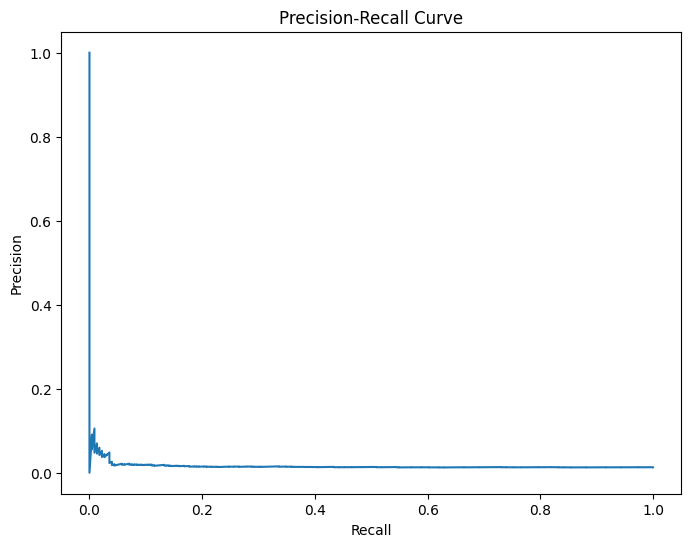

In [42]:
# Plot the precision-recall curve.

plt.figure(figsize=(8, 6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

## Model Evaluation Summary

The baseline Logistic Regression model was evaluated using multiple metrics because the repeat-purchase outcome is highly imbalanced.

- **Confusion Matrix:** The model predicted all 17,269 testing customers as non-returners, correctly identifying 17,043 non-returners but missing all 226 actual returners.
- **Accuracy:** Approximately 99%, but this is misleading because non-returners make up the overwhelming majority of the testing set.
- **Precision:** 0.00 for the repeat-purchase class because the model made no positive predictions.
- **Recall:** 0.00 for the repeat-purchase class because the model identified none of the 226 actual returners.
- **F1 Score:** 0.00 for the repeat-purchase class because both precision and recall were zero.
- **ROC-AUC:** 0.5048, indicating performance close to random ranking.
- **PR-AUC:** 0.0153, only slightly above the approximately 1.31% repeat-purchase rate in the testing set.

These results indicate that the baseline model has very limited ability to distinguish customers who will make a repeat purchase from those who will not.

## Baseline Model Summary

The Logistic Regression model provides a useful baseline, but the results show that the initial feature set contains very limited predictive signal for repeat purchases within 90 days.

Key findings:

- The positive class is highly imbalanced.
- The default 0.50 threshold predicts no repeat purchasers.
- ROC-AUC is approximately **0.5048**, which is close to random ranking.
- PR-AUC is approximately **0.0153**.
- The testing-set positive rate is approximately **1.31%**.
- The model's highest predicted probabilities are still relatively low.

This does **not** mean predictive modeling is useless for the project. It means this particular baseline, using this particular feature set and target definition, provides very little predictive power.

The baseline now gives us a reference point against which alternative modeling approaches and additional feature engineering can be evaluated.